# Baseline Exact GPR Model for PM2.5 Prediction

This notebook implements a baseline Gaussian Process Regression model for predicting PM2.5 concentrations in Montana.

## Scope
- **Region**: Montana (56 monitoring sites)
- **Time period**: 2018-2019
- **Model**: Exact GP with random mini-batch training
- **Target**: PM2.5 concentration

## Covariates (based on Swanson et al.)

### Time-varying (from pm_all)
- `aot` - Aerosol Optical Depth
- `wind` - 10m wind speed (r=-0.217 with winter PM2.5)
- `hgt` - Geopotential height (r=0.211)
- `cld` - Boundary layer cloud cover (r=-0.179)
- `longwave` - Upward longwave radiation (r=0.182)
- `rh` - Relative humidity (r=-0.185)
- `tmax` - Maximum temperature
- `smogI` - Smog intensity index
- `smogP` - Smog potential (GBM model; integration of pollution sources and topography)

### Static (from pm_fixed)
- `lat`, `lon` - Coordinates for spatial GP kernel
- `logpd2500g` - Log population density (r=0.722, strongest predictor)
- `minf_5000` - Local minima function, 5km radius (r=-0.499 to -0.605)
- `sd50k` - Terrain roughness (std elevation within 50km)
- `heavy_industrial_ind1` - Heavy industrial area (r=0.345)
- `housing` - Housing units

In [1]:
import sys
sys.path.insert(0, '../..')
import pandas as pd
import numpy as np
import torch
import gpytorch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import timing utilities
from timing_utils import TimingLogger, Timer

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize timing logger
timing_log = TimingLogger("../../timings/gpr_timings.csv", experiment_name="baseline_random_split")
print("Timing will be logged to timings/gpr_timings.csv")

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Timing will be logged to timings/gpr_timings.csv


## 1. Load and Filter Data

In [2]:
# Load datasets
pm_all = pd.read_csv("../../../data/pm25_data_complete_2003_2021_smogI_031026.csv", low_memory=False)
pm_fixed = pd.read_csv('../../../eda/pm25_locs_with_states.csv')

print(f"pm_all: {len(pm_all):,} rows")
print(f"pm_fixed: {len(pm_fixed):,} rows")

pm_all: 2,077,111 rows
pm_fixed: 975 rows


In [3]:
# Filter pm_fixed to Montana sites
mt_sites = pm_fixed[pm_fixed['state'] == 'MT'].copy()
print(f"Montana monitoring sites: {len(mt_sites)}")

# Get the ll_id values for Montana sites
mt_ll_ids = set(mt_sites['ll_id'].values)
print(f"Montana ll_ids: {len(mt_ll_ids)}")

Montana monitoring sites: 56
Montana ll_ids: 56


In [4]:
# Parse date and filter to 2019
pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')
pm_all['year'] = pm_all['date'].dt.year

# Filter to Montana sites and year 2019
pm_mt = pm_all[(pm_all['ll_id'].isin(mt_ll_ids)) & (pm_all['year'].isin([2018, 2019]))].copy()
print(f"Montana 2019 observations: {len(pm_mt):,}")
print(f"Unique sites in 2019: {pm_mt['ll_id'].nunique()}")
print(f"Date range: {pm_mt['date'].min()} to {pm_mt['date'].max()}")

Montana 2019 observations: 15,572
Unique sites in 2019: 32
Date range: 2018-01-01 00:00:00 to 2019-12-31 00:00:00


PM2.5 summary statistics:
count    15572.000000
mean         6.369645
std          6.817235
min          0.000000
25%          2.500000
50%          4.500000
75%          7.600000
max        115.200000
Name: pm25, dtype: float64


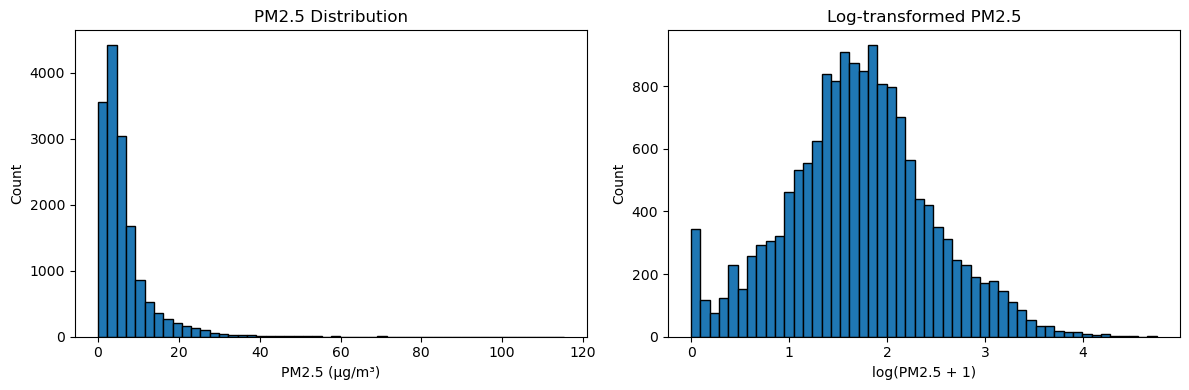

In [5]:
# Check PM2.5 distribution
print(f"PM2.5 summary statistics:")
print(pm_mt['pm25'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pm_mt['pm25'], bins=50, edgecolor='black')
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Count')
axes[0].set_title('PM2.5 Distribution')

axes[1].hist(np.log(pm_mt['pm25'] + 1), bins=50, edgecolor='black')
axes[1].set_xlabel('log(PM2.5 + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-transformed PM2.5')
plt.tight_layout()
plt.show()

## 2. Select and Merge Features

In [6]:
# Define feature sets
time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 
                   'heavy_industrial_ind1', 'housing']

# Check which time-varying features are available
available_tv = [f for f in time_varying_features if f in pm_mt.columns]
missing_tv = [f for f in time_varying_features if f not in pm_mt.columns]
print(f"Available time-varying features: {available_tv}")
print(f"Missing time-varying features: {missing_tv}")

Available time-varying features: ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
Missing time-varying features: []


In [7]:
# Select columns from pm_all
pm_mt_subset = pm_mt[['ll_id', 'date', 'pm25'] + available_tv].copy()

# Select static features from pm_fixed for Montana
available_static = [f for f in static_features if f in mt_sites.columns]
missing_static = [f for f in static_features if f not in mt_sites.columns]
print(f"Available static features: {available_static}")
print(f"Missing static features: {missing_static}")

mt_static = mt_sites[['ll_id'] + available_static].copy()

Available static features: ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']
Missing static features: []


In [8]:
# Merge time-varying and static data
df = pm_mt_subset.merge(mt_static, on='ll_id', how='left')
print(f"Merged dataset: {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

Merged dataset: 15,572 rows, 19 columns

Columns: ['ll_id', 'date', 'pm25', 'aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']


In [9]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal rows with any missing: {df.isnull().any(axis=1).sum()}")

Missing values per column:
Series([], dtype: int64)

Total rows with any missing: 0


In [10]:
# Define final feature list (all covariates)
feature_cols = available_tv + available_static
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Drop rows with missing values in features or target
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()
print(f"\nClean dataset: {len(df_clean):,} rows ({100*len(df_clean)/len(df):.1f}% retained)")

Feature columns (16): ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']

Clean dataset: 15,572 rows (100.0% retained)


## 3. Prepare Data for GPR

In [11]:
# Extract features and target
X = df_clean[feature_cols].values
y = df_clean['pm25'].values

# Log-transform target (PM2.5 is right-skewed)
y_log = np.log(y + 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_log range: [{y_log.min():.3f}, {y_log.max():.3f}]")

X shape: (15572, 16)
y shape: (15572,)
y_log range: [0.000, 4.755]


In [12]:
# Train/test split (80/20, stratified by site to avoid data leakage)
# Using random split for now - can improve with spatial/temporal CV later
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

Training set: 12,457 samples
Test set: 3,115 samples


In [13]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
train_x = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
train_y = torch.tensor(y_train, dtype=torch.float32).to(device)
test_x = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
test_y = torch.tensor(y_test, dtype=torch.float32).to(device)

print(f"train_x: {train_x.shape}, train_y: {train_y.shape}")
print(f"test_x: {test_x.shape}, test_y: {test_y.shape}")

train_x: torch.Size([12457, 16]), train_y: torch.Size([12457])
test_x: torch.Size([3115, 16]), test_y: torch.Size([3115])


## 4. Define Exact GP Model

In [14]:
class ExactGPModel(gpytorch.models.ExactGP):
    """Exact GP model with RBF kernel + constant mean."""
    
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        
        # RBF kernel with ARD (separate lengthscale per feature)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=train_x.shape[1])
        )
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [15]:
# For exact GP with large datasets, we need to subsample
# Start with a random subset for initial training
MAX_TRAIN_SIZE = 4000  # Exact GP scales O(n³), so keep this manageable

if len(train_x) > MAX_TRAIN_SIZE:
    # Random subsample for training
    indices = torch.randperm(len(train_x))[:MAX_TRAIN_SIZE]
    train_x_subset = train_x[indices]
    train_y_subset = train_y[indices]
    print(f"Subsampled training data: {len(train_x_subset)} samples")
else:
    train_x_subset = train_x
    train_y_subset = train_y
    print(f"Using full training data: {len(train_x_subset)} samples")

Subsampled training data: 4000 samples


In [16]:
# Initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
model = ExactGPModel(train_x_subset, train_y_subset, likelihood).to(device)

print("Model structure:")
print(model)

Model structure:
ExactGPModel(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): RBFKernel(
      (raw_lengthscale_constraint): Positive()
    )
    (raw_outputscale_constraint): Positive()
  )
)


## 5. Train the Model

In [17]:
# Training settings
model.train()
likelihood.train()

# Use Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Loss function: negative log marginal likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

n_epochs = 50
losses = []

# Time the training (hyperparameter learning)
with timing_log.time("training", years="2018-2019", 
                     n_train=len(train_x_subset), 
                     n_features=train_x_subset.shape[1],
                     n_epochs=n_epochs,
                     kernel="RBF_ARD"):
    for i in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x_subset)
        loss = -mll(output, train_y_subset)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if (i + 1) % 20 == 0:
            print(f"Epoch {i+1}/{n_epochs}, Loss: {loss.item():.4f}")

print(f"Final loss: {losses[-1]:.4f}")

Epoch 20/50, Loss: 0.7380


Epoch 40/50, Loss: 0.6913


[training] 1.902s (years=2018-2019, n_train=4000, n_features=16, n_epochs=50, kernel=RBF_ARD)
Final loss: 0.6885


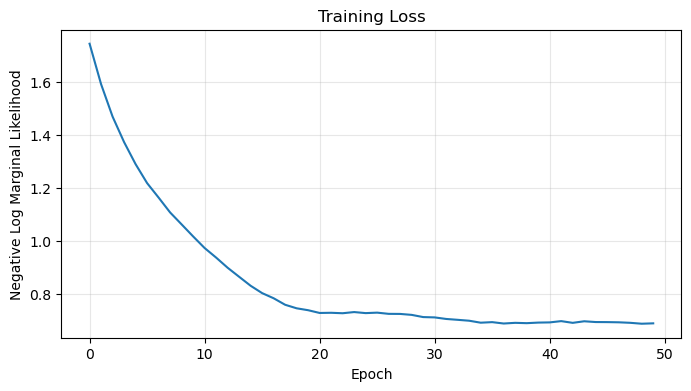

In [18]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Negative Log Marginal Likelihood')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Inspect learned hyperparameters
print("Learned hyperparameters:")
print(f"  Noise variance: {likelihood.noise.item():.4f}")
print(f"  Output scale: {model.covar_module.outputscale.item():.4f}")
print(f"  Lengthscales (ARD):")
lengthscales = model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().flatten()
for feat, ls in zip(feature_cols, lengthscales):
    print(f"    {feat}: {ls:.4f}")

Learned hyperparameters:
  Noise variance: 0.1886
  Output scale: 0.2995
  Lengthscales (ARD):
    aot: 2.4242
    wind: 2.5678
    hgt: 2.6056
    cld: 2.3495
    longwave: 2.0218
    rh: 2.1036
    tmax: 2.0952
    smogI: 2.2901
    smogP: 1.7393
    lat: 2.1203
    lon: 2.1485
    logpd2500g: 2.5101
    minf_5000: 2.3826
    sd50k: 2.6154
    heavy_industrial_ind1: 2.9392
    housing: 2.5974


## 6. Evaluate on Test Set

In [20]:
# Switch to evaluation mode
model.eval()
likelihood.eval()

# Make predictions with timing
batch_size = 500
means = []
variances = []

with timing_log.time("inference", years="2018-2019", 
                     n_train=len(train_x_subset),
                     n_test=len(test_x), 
                     n_features=test_x.shape[1],
                     batch_size=batch_size):
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(test_x), batch_size):
            batch_x = test_x[i:i+batch_size]
            pred = likelihood(model(batch_x))
            means.append(pred.mean.cpu())
            variances.append(pred.variance.cpu())
        
        pred_mean = torch.cat(means).numpy()
        pred_var = torch.cat(variances).numpy()

print(f"Predictions shape: {pred_mean.shape}")

[inference] 0.091s (years=2018-2019, n_train=4000, n_test=3115, n_features=16, batch_size=500)
Predictions shape: (3115,)


In [21]:
# Calculate metrics on log scale
y_test_np = test_y.cpu().numpy()

# RMSE on log scale
rmse_log = np.sqrt(np.mean((pred_mean - y_test_np)**2))

# R² on log scale
ss_res = np.sum((y_test_np - pred_mean)**2)
ss_tot = np.sum((y_test_np - np.mean(y_test_np))**2)
r2_log = 1 - (ss_res / ss_tot)

# MAE on log scale
mae_log = np.mean(np.abs(pred_mean - y_test_np))

print("Metrics on log(PM2.5 + 1) scale:")
print(f"  RMSE: {rmse_log:.4f}")
print(f"  MAE:  {mae_log:.4f}")
print(f"  R²:   {r2_log:.4f}")

Metrics on log(PM2.5 + 1) scale:
  RMSE: 0.4635
  MAE:  0.3527
  R²:   0.6193


In [22]:
# Transform back to original scale
pred_pm25 = np.exp(pred_mean) - 1
actual_pm25 = np.exp(y_test_np) - 1

# Metrics on original scale
rmse_orig = np.sqrt(np.mean((pred_pm25 - actual_pm25)**2))
mae_orig = np.mean(np.abs(pred_pm25 - actual_pm25))
ss_res_orig = np.sum((actual_pm25 - pred_pm25)**2)
ss_tot_orig = np.sum((actual_pm25 - np.mean(actual_pm25))**2)
r2_orig = 1 - (ss_res_orig / ss_tot_orig)

print("\nMetrics on original PM2.5 scale (μg/m³):")
print(f"  RMSE: {rmse_orig:.2f}")
print(f"  MAE:  {mae_orig:.2f}")
print(f"  R²:   {r2_orig:.4f}")


Metrics on original PM2.5 scale (μg/m³):
  RMSE: 4.60
  MAE:  2.55
  R²:   0.5356


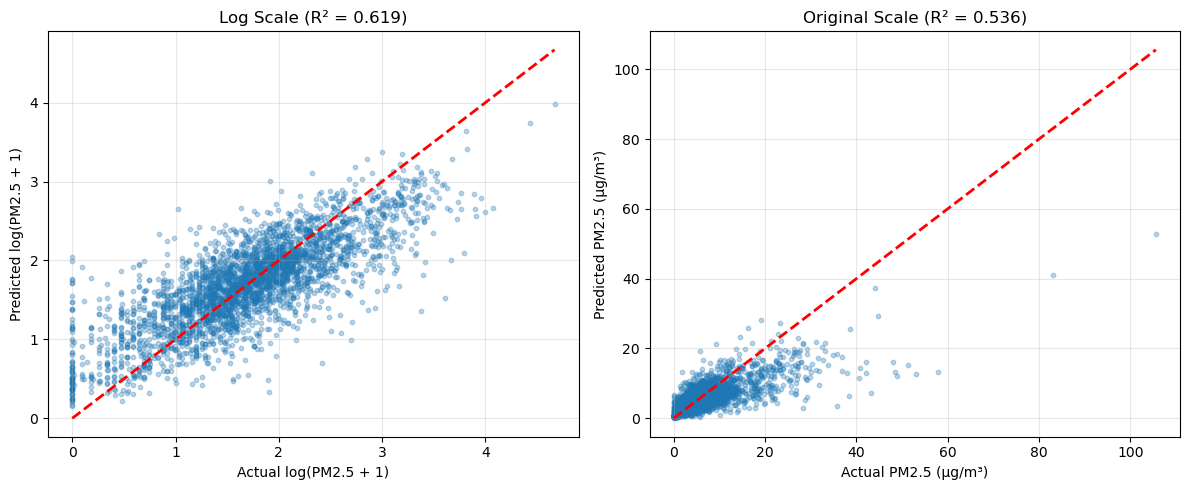

In [23]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Log scale
axes[0].scatter(y_test_np, pred_mean, alpha=0.3, s=10)
axes[0].plot([y_test_np.min(), y_test_np.max()], 
             [y_test_np.min(), y_test_np.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Log Scale (R² = {r2_log:.3f})')
axes[0].grid(True, alpha=0.3)

# Original scale
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.3, s=10)
max_val = max(actual_pm25.max(), pred_pm25.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (μg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[1].set_title(f'Original Scale (R² = {r2_orig:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

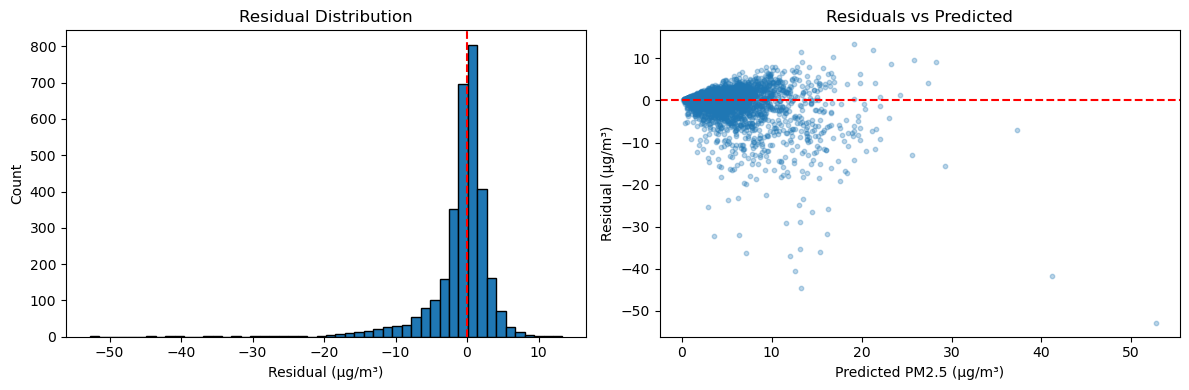

Residual statistics:
  Mean: -0.859
  Std:  4.520
  Min:  -52.810
  Max:  13.348


In [24]:
# Residual analysis
residuals = pred_pm25 - actual_pm25

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residual distribution
axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Residual (μg/m³)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution')

# Residuals vs predicted
axes[1].scatter(pred_pm25, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (μg/m³)')
axes[1].set_ylabel('Residual (μg/m³)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

print(f"Residual statistics:")
print(f"  Mean: {residuals.mean():.3f}")
print(f"  Std:  {residuals.std():.3f}")
print(f"  Min:  {residuals.min():.3f}")
print(f"  Max:  {residuals.max():.3f}")

## 7. Feature Importance (via ARD Lengthscales)

In ARD (Automatic Relevance Determination), shorter lengthscales indicate more important features.

In [25]:
# Feature importance from ARD lengthscales
# Smaller lengthscale = more important (function varies more rapidly with that feature)
importance = 1.0 / lengthscales
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'lengthscale': lengthscales,
    'importance': importance
}).sort_values('importance', ascending=False)

print("Feature importance (1/lengthscale):")
print(importance_df.to_string(index=False))

Feature importance (1/lengthscale):
              feature  lengthscale  importance
                smogP     1.739291    0.574947
             longwave     2.021821    0.494604
                 tmax     2.095213    0.477279
                   rh     2.103570    0.475382
                  lat     2.120326    0.471626
                  lon     2.148523    0.465436
                smogI     2.290135    0.436655
                  cld     2.349477    0.425627
            minf_5000     2.382577    0.419714
                  aot     2.424160    0.412514
           logpd2500g     2.510121    0.398387
                 wind     2.567755    0.389445
              housing     2.597420    0.384997
                  hgt     2.605622    0.383786
                sd50k     2.615427    0.382347
heavy_industrial_ind1     2.939168    0.340232


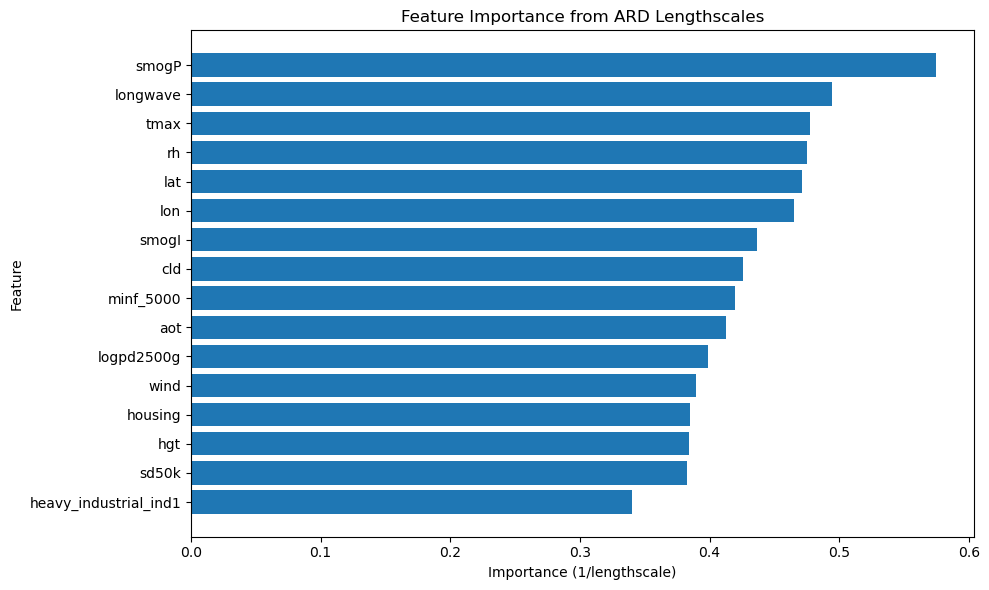

In [26]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance (1/lengthscale)')
plt.ylabel('Feature')
plt.title('Feature Importance from ARD Lengthscales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Collinearity Check: Longwave vs Tmax

Longwave radiation and tmax are expected to be correlated (warmer surfaces emit more longwave). Here we drop `longwave` and retrain the model to quantify how much unique information it contributes beyond `tmax`.

Pearson correlation (longwave, tmax): 0.9812


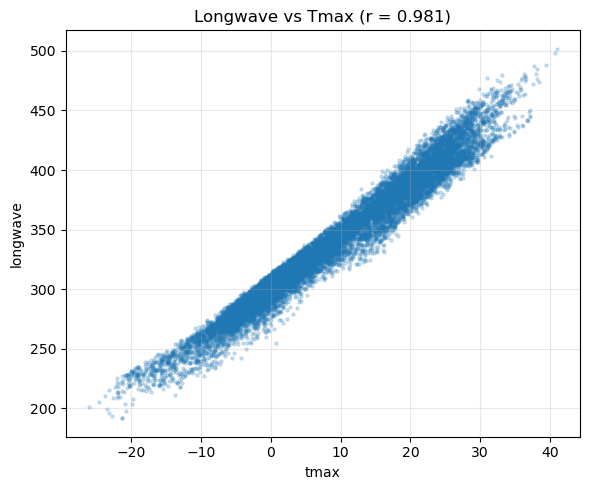

In [27]:
# Correlation between longwave and tmax
corr = df_clean['longwave'].corr(df_clean['tmax'])
print(f"Pearson correlation (longwave, tmax): {corr:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_clean['tmax'], df_clean['longwave'], alpha=0.2, s=5)
ax.set_xlabel('tmax')
ax.set_ylabel('longwave')
ax.set_title(f'Longwave vs Tmax (r = {corr:.3f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Retrain model without longwave, using the same train/test split and subsample seed
feature_cols_no_lw = [f for f in feature_cols if f != 'longwave']
lw_idx = feature_cols.index('longwave')

# Remove longwave column from the already-split arrays
X_train_no_lw = np.delete(X_train, lw_idx, axis=1)
X_test_no_lw = np.delete(X_test, lw_idx, axis=1)

# Re-scale
scaler_no_lw = StandardScaler()
X_train_no_lw_scaled = scaler_no_lw.fit_transform(X_train_no_lw)
X_test_no_lw_scaled = scaler_no_lw.transform(X_test_no_lw)

# Convert to tensors
train_x_no_lw = torch.tensor(X_train_no_lw_scaled, dtype=torch.float32).to(device)
test_x_no_lw = torch.tensor(X_test_no_lw_scaled, dtype=torch.float32).to(device)

# Use the same subsample indices as the full model
train_x_no_lw_subset = train_x_no_lw[indices]
train_y_no_lw_subset = train_y[indices]

# Train
torch.manual_seed(42)
likelihood_no_lw = gpytorch.likelihoods.GaussianLikelihood().to(device)
model_no_lw = ExactGPModel(train_x_no_lw_subset, train_y_no_lw_subset, likelihood_no_lw).to(device)

model_no_lw.train()
likelihood_no_lw.train()
optimizer_no_lw = torch.optim.Adam(model_no_lw.parameters(), lr=0.1)
mll_no_lw = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_no_lw, model_no_lw)

n_epochs_no_lw = 100
losses_no_lw = []
for i in range(n_epochs_no_lw):
    optimizer_no_lw.zero_grad()
    output = model_no_lw(train_x_no_lw_subset)
    loss = -mll_no_lw(output, train_y_no_lw_subset)
    loss.backward()
    optimizer_no_lw.step()
    losses_no_lw.append(loss.item())

print(f"Final loss (no longwave): {losses_no_lw[-1]:.4f}  (full model: {losses[-1]:.4f})")

# Evaluate
model_no_lw.eval()
likelihood_no_lw.eval()
means_no_lw = []
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    for i in range(0, len(test_x_no_lw), 500):
        batch = test_x_no_lw[i:i+500]
        pred = likelihood_no_lw(model_no_lw(batch))
        means_no_lw.append(pred.mean.cpu())
pred_mean_no_lw = torch.cat(means_no_lw).numpy()

# Metrics on log scale
rmse_log_no_lw = np.sqrt(np.mean((pred_mean_no_lw - y_test_np)**2))
ss_res_no_lw = np.sum((y_test_np - pred_mean_no_lw)**2)
r2_log_no_lw = 1 - (ss_res_no_lw / ss_tot)

# Metrics on original scale
pred_pm25_no_lw = np.exp(pred_mean_no_lw) - 1
rmse_orig_no_lw = np.sqrt(np.mean((pred_pm25_no_lw - actual_pm25)**2))
ss_res_orig_no_lw = np.sum((actual_pm25 - pred_pm25_no_lw)**2)
r2_orig_no_lw = 1 - (ss_res_orig_no_lw / ss_tot_orig)

# Comparison table
print("\n--- Comparison: Full model vs No-longwave ---")
print(f"{'Metric':<30} {'Full model':>12} {'No longwave':>12} {'Delta':>10}")
print("-" * 66)
print(f"{'R² (log scale)':<30} {r2_log:>12.4f} {r2_log_no_lw:>12.4f} {r2_log_no_lw - r2_log:>+10.4f}")
print(f"{'RMSE (log scale)':<30} {rmse_log:>12.4f} {rmse_log_no_lw:>12.4f} {rmse_log_no_lw - rmse_log:>+10.4f}")
print(f"{'R² (original scale)':<30} {r2_orig:>12.4f} {r2_orig_no_lw:>12.4f} {r2_orig_no_lw - r2_orig:>+10.4f}")
print(f"{'RMSE (original, ug/m3)':<30} {rmse_orig:>12.2f} {rmse_orig_no_lw:>12.2f} {rmse_orig_no_lw - rmse_orig:>+10.2f}")

# Show how tmax lengthscale changes when longwave is removed
ls_no_lw = model_no_lw.covar_module.base_kernel.lengthscale.detach().cpu().numpy().flatten()
tmax_idx_no_lw = feature_cols_no_lw.index('tmax')
tmax_ls_full = lengthscales[feature_cols.index('tmax')]
tmax_ls_no_lw = ls_no_lw[tmax_idx_no_lw]
print(f"\ntmax lengthscale: {tmax_ls_full:.4f} (full) -> {tmax_ls_no_lw:.4f} (no longwave)")
print("  (shorter = tmax absorbs more of the variance longwave was explaining)")

Final loss (no longwave): 0.6799  (full model: 0.6885)

--- Comparison: Full model vs No-longwave ---
Metric                           Full model  No longwave      Delta
------------------------------------------------------------------
R² (log scale)                       0.6193       0.6199    +0.0005
RMSE (log scale)                     0.4635       0.4632    -0.0003
R² (original scale)                  0.5356       0.5402    +0.0046
RMSE (original, ug/m3)                 4.60         4.58      -0.02

tmax lengthscale: 2.0952 (full) -> 1.6452 (no longwave)
  (shorter = tmax absorbs more of the variance longwave was explaining)


## 9. Summary and Next Steps

### Model Summary
- Exact GP with RBF kernel and ARD
- Trained on subset of Montana 2018-2019 data
- Log-transformed PM2.5 target

### Potential Improvements
1. **Spatial cross-validation**: Use leave-one-site-out or spatial blocking to avoid data leakage
2. **Temporal features**: Add day-of-year, month, or seasonal indicators
3. **More covariates**: LST climatology, additional terrain features
4. **Kernel exploration**: Try Matérn kernel, periodic kernels for seasonality
5. **Sparse GP**: Use inducing points to scale to full dataset
6. **Ensemble**: Combine multiple GPs trained on different subsets

In [29]:
import os
# Save overall results
results = {
    'years': '2018-2019',
    'cv_method': 'Random_Split',
    'n_train': len(train_x_subset),
    'n_test': len(test_x),
    'n_predictions': len(pred_mean),
    'rmse_log': rmse_log,
    'mae_log': mae_log,
    'r2_log': r2_log,
    'rmse_orig': rmse_orig,
    'mae_orig': mae_orig,
    'r2_orig': r2_orig,
}
results_path = '../../results/baseline_overall_results.csv'
new_row = pd.DataFrame([results])
if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    pd.concat([existing, new_row], ignore_index=True).to_csv(results_path, index=False)
else:
    new_row.to_csv(results_path, index=False)
print(f'Results saved to {results_path}')

Results saved to ../../results/baseline_overall_results.csv


In [30]:
# Save model state for later use
torch.save({
    'model_state_dict': model.state_dict(),
    'likelihood_state_dict': likelihood.state_dict(),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'feature_cols': feature_cols,
}, '../../models/baseline_gpr_model.pt')

print("Model saved to models/baseline_gpr_model.pt")

# Display timing summary
timing_log.summary()

Model saved to models/baseline_gpr_model.pt

Timing Summary: ../../timings/gpr_timings.csv

training:
  Count: 10
  Mean:  2.454s
  Std:   0.628s
  Min:   1.758s
  Max:   3.316s

inference:
  Count: 10
  Mean:  0.097s
  Std:   0.026s
  Min:   0.079s
  Max:   0.166s

loso_cv_total:
  Count: 10
  Mean:  43.446s
  Std:   3.884s
  Min:   38.804s
  Max:   49.625s

spatial_cv_total:
  Count: 2
  Mean:  9.353s
  Std:   1.228s
  Min:   8.485s
  Max:   10.221s

periodic_loso_cv_total:
  Count: 3
  Mean:  53.303s
  Std:   4.694s
  Min:   49.704s
  Max:   58.612s


,timestamp,experiment,operation,n_train,n_features,n_epochs,kernel,elapsed_seconds,n_test,batch_size,n_folds,years
0,2026-02-08T19:35:27.914688,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,3.048240,NaN,NaN,NaN,2019
1,2026-02-08T19:35:31.067357,baseline_random_split,inference,2000.0,16,NaN,NaN,0.079156,1511.0,500.0,NaN,2019
2,2026-02-08T19:36:36.901326,loso_cv,loso_cv_total,NaN,16,50.0,NaN,45.539098,NaN,NaN,28.0,2019
3,2026-02-08T19:37:05.013040,spatial_cv,spatial_cv_total,NaN,16,50.0,NaN,8.484749,NaN,NaN,5.0,2019
4,2026-02-10T14:45:12.636565,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,3.316486,NaN,NaN,NaN,2019
5,2026-02-10T14:45:16.055818,baseline_random_split,inference,2000.0,16,NaN,NaN,0.080925,1511.0,500.0,NaN,2019
6,2026-02-10T18:55:48.904301,loso_cv,loso_cv_total,NaN,16,50.0,NaN,41.388759,NaN,NaN,28.0,2019
7,2026-02-10T19:18:24.395793,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,2.934810,NaN,NaN,NaN,2018-2019
8,2026-02-10T19:18:27.423776,baseline_random_split,inference,2000.0,16,NaN,NaN,0.085181,3016.0,500.0,NaN,2018-2019
9,2026-02-10T19:19:45.717205,loso_cv,loso_cv_total,NaN,16,50.0,NaN,42.562510,NaN,NaN,28.0,2018-2019
